# 04 · The backtest

Part 4 of 5. The strategy is run over January 2020 to September 2026 and compared with its variants.

**Rules.**

1. Every 21 trading days, sell an at-the-money straddle with 21 trading days to expiry. The notional equals the capital (1,000,000), and the position is held to expiry.
2. The implied volatility used for pricing is `VIX − 2 points`. The VIX is built from options across all strikes and sits above the at-the-money level because of the put skew, so using it directly would overstate the premium.
3. The delta hedge is rebalanced every day at the close.
4. Costs: a half-spread of 0.25 vol points on the option at entry, and 1 bp on every trade in the index.
5. The straddle is marked every day at the prevailing implied volatility.

**Variants.** The same trade without the hedge, and three filtered versions that only sell when `VIX − HAR-X forecast` exceeds 0, 2 or 4 vol points. The forecast is the walk-forward HAR-X of notebook 02, so the filter uses nothing that was unknown at the time.

Returns are P&L divided by the fixed capital, and they are not compounded.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

from vrp.data import load_market_data
from vrp.volatility import forward_realized_variance, log_returns

END = "2026-09-25"                   # last complete session used for the published results
EVAL_START = pd.Timestamp("2020-01-01")

data = load_market_data("yahoo", "1990-01-01", END)
spx, vix = data["spx"], data["vix"]
returns = log_returns(spx)
realized_var = forward_realized_variance(returns)   # RV(t, t+21), annualised
realized_vol = np.sqrt(realized_var)
implied_var = (vix / 100) ** 2
print(f"{len(data):,} daily observations, {spx.index[0].date()} to {spx.index[-1].date()}")

9,251 daily observations, 1990-01-02 to 2026-09-25


In [2]:
from vrp.backtest import StraddleConfig
from vrp.pipeline import run_strategies, summarize_strategies
from vrp.report import as_percent
from vrp.volatility import walk_forward_har

har_x, _ = walk_forward_har(returns, implied_variance=implied_var)
first = max(EVAL_START, har_x.first_valid_index())
sample, vix_sample = spx.loc[first:], vix.loc[first:]

base = StraddleConfig()
runs = run_strategies(sample, vix_sample, har_x, base)
returns_by_strategy, summary = summarize_strategies(runs)
print(f"Backtest window: {sample.index[0].date()} to {sample.index[-1].date()} ({len(sample):,} trading days)")

Backtest window: 2020-01-02 to 2026-09-25 (1,692 trading days)


In [3]:
columns = ["ann_return", "ann_vol", "sharpe", "max_drawdown", "worst_month", "skew", "cvar_99", "months_traded", "psr_vs_0", "deflated_sharpe"]
table = as_percent(summary[columns], ["ann_return", "ann_vol", "max_drawdown", "worst_month", "cvar_99"])
table["months_traded"] = table["months_traded"].astype(int)
table.round(2)

,ann_return (%),ann_vol (%),sharpe,max_drawdown (%),worst_month (%),skew,cvar_99 (%),months_traded,psr_vs_0,deflated_sharpe
strategy,,,,,,,,,,
"Short straddle, delta-hedged",3.9,5.6,0.70,-13.6,-8.3,-3.79,2.2,80,0.95,0.69
"Short straddle, unhedged",0.0,13.1,0.00,-24.2,-9.0,-1.18,4.1,80,0.50,0.10
VRP filter > 0 vol pts,5.0,5.1,0.97,-6.5,-3.0,-3.86,2.0,78,0.99,0.86
VRP filter > 2 vol pts,4.5,5.0,0.89,-6.5,-3.0,-4.06,2.0,68,0.98,0.82
VRP filter > 4 vol pts,3.1,3.2,0.98,-4.6,-1.2,-7.22,1.2,19,0.98,0.84


- **ann_return / ann_vol / sharpe**: mean and standard deviation of daily returns on capital, annualized.
- **skew**: negative means the losses are larger than the gains are frequent.
- **cvar_99**: average daily loss on the worst 1% of days.
- **psr_vs_0** and **deflated_sharpe**: probability that the true Sharpe ratio is above zero (Bailey and López de Prado), the second one after correcting for having tried five variants. Both account for the fat tails of the returns.

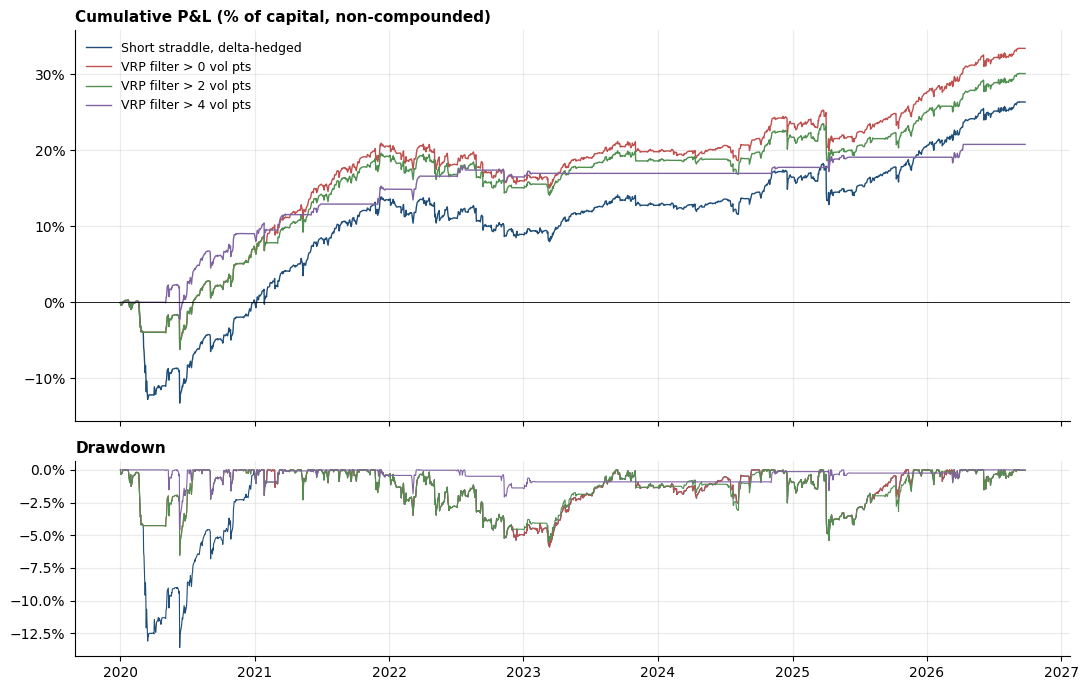

In [4]:
from vrp.plots import plot_equity

plot_equity({k: v for k, v in returns_by_strategy.items() if k != "Short straddle, unhedged"})

The top panel is cumulative P&L, the bottom panel the drawdown from the previous peak. In the Covid crash the unfiltered strategy (blue) loses about 13% and only gets back to zero at the end of 2020. The filtered versions come out of it with a loss of about 4% (or nothing, for the 4-point filter), because they had no position open when the crash began. The lead this gives them is about 7 points of capital at the end of the sample, and the curves move broadly together after 2020.

## Why hedge?

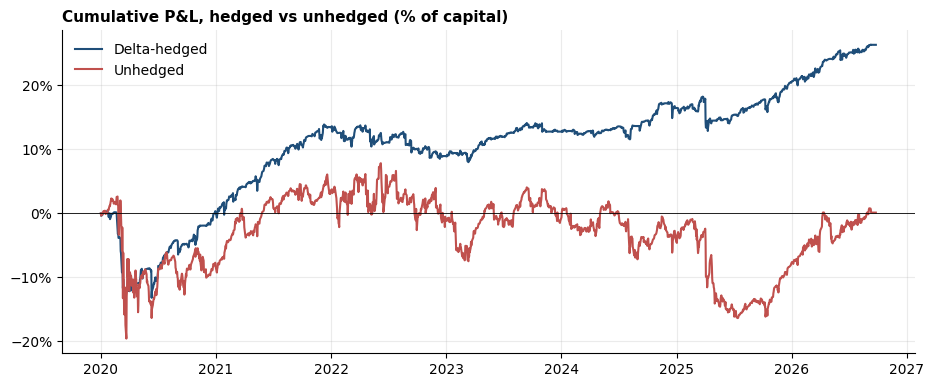

In [5]:
from vrp.plots import PALETTE, style

hedged = returns_by_strategy["Short straddle, delta-hedged"]
unhedged = returns_by_strategy["Short straddle, unhedged"]
fig, ax = plt.subplots(figsize=(11, 4.2))
ax.plot(hedged.index, hedged.cumsum(), color=PALETTE[0], label="Delta-hedged")
ax.plot(unhedged.index, unhedged.cumsum(), color=PALETTE[1], label="Unhedged")
ax.axhline(0, color="black", lw=0.6)
ax.yaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))
ax.legend(frameon=False)
style(ax, "Cumulative P&L, hedged vs unhedged (% of capital)")
plt.close(fig)
fig

Without the hedge, the result of each trade depends on how far the index ends from the strike at expiry, not only on how much it moved day to day. A steady trend costs the seller money even when daily volatility is low, and the P&L becomes a mix of the volatility bet and a directional bet. Over this window the unhedged version earns nothing, with a maximum drawdown of 24% against 14% for the hedged one. The hedge removes the directional part and leaves the bet the strategy is meant to make.

## Where the money comes from

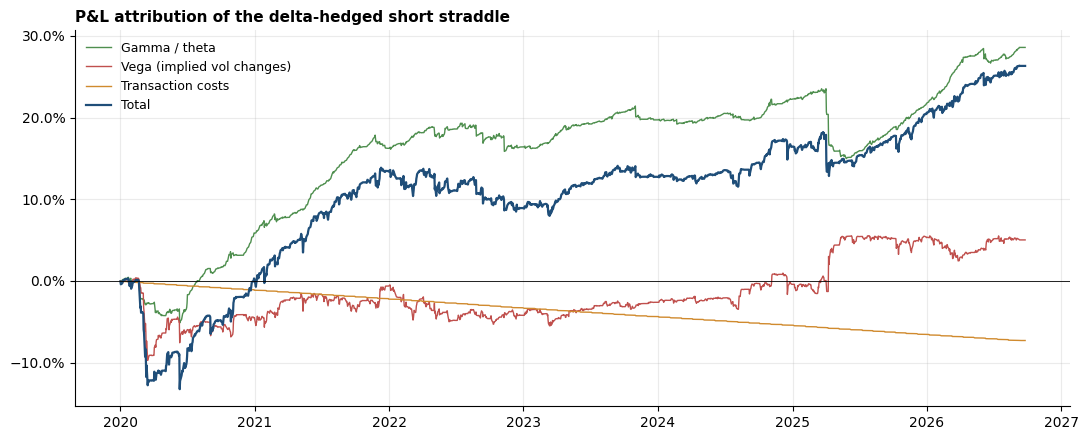

In [6]:
from vrp.plots import plot_attribution

main_daily, main_trades = runs["Short straddle, delta-hedged"]
plot_attribution(main_daily, base.capital)

In [7]:
parts = pd.Series({
    "gamma / theta": main_daily["gamma_theta_pnl"].sum(),
    "vega": main_daily["vega_pnl"].sum(),
    "costs": -main_daily["costs"].sum(),
    "total": main_daily["pnl"].sum(),
}) / base.capital
(100 * parts).round(1).rename("cumulative P&L (% of capital)").to_frame()

,cumulative P&L (% of capital)
gamma / theta,28.6
vega,5.0
costs,-7.3
total,26.3


The P&L is split into three pieces. **Gamma/theta** is the pure volatility bet: the time decay collected minus the cost of the index moving. **Vega** is the effect of the VIX itself changing during the life of the trade. **Costs** are the option half-spread at entry and the hedging trades.

## Return distribution

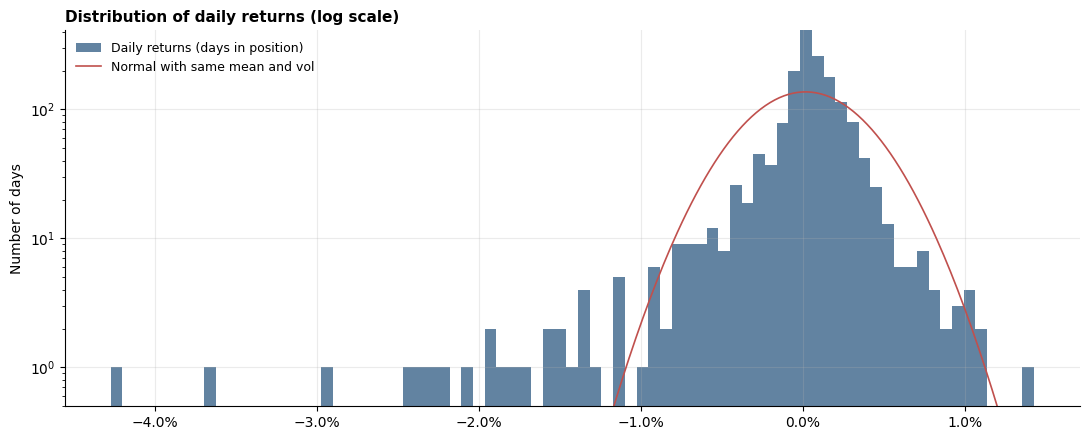

In [8]:
from vrp.plots import plot_return_distribution

plot_return_distribution(main_daily["return"])

The histogram is on a log scale so that the tails stay visible. The red curve is a normal distribution with the same mean and volatility. The real returns have more mass around zero and a much longer left tail: many quiet days, and a handful of days far worse than a normal distribution allows.

In [9]:
in_position = main_daily.loc[main_daily["in_position"] == 1, "return"]
z = (in_position.min() - in_position.mean()) / in_position.std()
display(Markdown(
    f"The worst day is {100 * in_position.min():.1f}% of capital, which is **{abs(z):.0f} standard deviations** below the average day "
    f"({in_position.std() * 100:.2f}% daily standard deviation while in position). A normal distribution would make a day like this practically impossible."
))

The worst day is -4.3% of capital, which is **12 standard deviations** below the average day (0.35% daily standard deviation while in position). A normal distribution would make a day like this practically impossible.

## Calendar years and individual trades

In [10]:
yearly = pd.DataFrame({name: 100 * r.groupby(r.index.year).sum() for name, r in returns_by_strategy.items()}).round(1)
yearly.index.name = "year (%, P&L on capital)"
yearly

,"Short straddle, delta-hedged","Short straddle, unhedged",VRP filter > 0 vol pts,VRP filter > 2 vol pts,VRP filter > 4 vol pts
"year (%, P&L on capital)",,,,,
2020,0.2,-8.4,7.3,7.3,9.0
2021,13.2,11.9,13.2,11.8,5.9
2022,-4.5,-4.3,-4.5,-4.1,1.6
2023,3.8,-0.4,3.8,3.5,0.5
2024,3.7,-3.2,3.7,3.1,0.8
2025,4.0,-3.4,4.0,3.3,1.3
2026,5.9,7.9,5.9,5.1,1.7


In [11]:
pnl = main_trades["pnl"] / base.capital
wins, losses = pnl[pnl > 0], pnl[pnl <= 0]
display(Markdown(
    f"**Delta-hedged strategy, {len(pnl)} trades.** Winning trades: {100 * len(wins) / len(pnl):.0f}%. "
    f"Average win {100 * wins.mean():.2f}% of capital, average loss {100 * losses.mean():.2f}%. "
    f"Best trade {100 * pnl.max():+.2f}%, worst trade {100 * pnl.min():+.2f}%."
))
main_trades.assign(pnl_pct=(100 * pnl).round(2)).nsmallest(5, "pnl")[["entry", "expiry", "implied_vol", "realized_vol", "pnl_pct"]].round(
    {"implied_vol": 3, "realized_vol": 3}).set_index("entry")

**Delta-hedged strategy, 80 trades.** Winning trades: 70%. Average win 0.97% of capital, average loss -1.16%. Best trade +2.44%, worst trade -8.22%.

,expiry,implied_vol,realized_vol,pnl_pct
entry,,,,
2020-03-04,2020-04-02,0.300,0.934,-8.22
2020-02-03,2020-03-04,0.160,0.336,-3.43
2025-03-10,2025-04-08,0.259,0.318,-2.57
2024-07-08,2024-08-06,0.104,0.197,-1.95
2022-06-02,2022-07-05,0.227,0.290,-1.18


The worst five trades are all months where realized volatility ended above the level charged at entry. Winning trades are 70% of the total and the average loss is only slightly larger than the average win, so the profile is not "many small gains, few huge losses" on average. The weight is in a single trade: the worst one (−8.2%) is about eight times the average win.

By calendar year, the hedged strategy is positive in every year except 2022 (−4.5%), the only losing year. The forecast filter changes 2020 (+7.3% against +0.2%) and hardly anything else: in 2022 it loses as much as the unfiltered version. The most selective filter (4 points) is positive every year but earns little, because it trades only 19 of 80 months.